# Question 1: Gekko Python-Based Optimization Suite

##  (b) Defining the unconstrained optimization problem

In [1]:
from gekko import GEKKO

# Here we initialize gekko model
gekko_model = GEKKO(remote=False)


# This is to define the variables 
x1 = gekko_model.Var()
x2 = gekko_model.Var()



# We want to minimize the provided function 
gekko_model.Minimize(x1**2 * gekko_model.exp(1 - x1**2) - 20.25*(x1 - x2)**2)



# Since the function is defined over the whole real number line, i.e unconstrained, 
# we use Interior Point Optimizer(IPOPT), i.e model model.options.solver = 3

gekko_model.options.SOLVER = 3 
gekko_model.solve(disp=False)



print("x1 =", x1.value[0])
print("x2 =", x2.value[0])


x1 = 0.0
x2 = 0.0


# Question 2:  Nonlinear Regression / Curve Fitting

In [3]:
import numpy as np

x = np.array([0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9,2.0])
y = np.array([5.8955,3.5639,2.5173,1.9790,1.8990,1.3938,1.1359,1.0096,1.0343,0.8435,0.6856,0.6100,0.5392,0.3946,0.3903,0.5474,0.3459,0.1370,0.2211,0.1704,0.2636])


## (a) Plotting data points on x–y axis

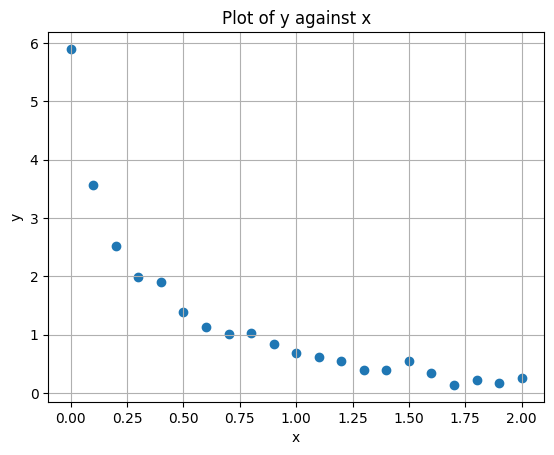

In [4]:
import matplotlib.pyplot as plt


plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Plot of y against x")
plt.grid(True)
plt.show()


## Interpretation: 
### The scatter plot reveals a strong decreasing trend. i.e. as x increases, y consistently decreases. For small values of x, y is relatively high, around 6, but for larger values of x, y is much smaller, below 0.5. 

## (b) Estimating the parameters  w1,w2,w3,w4 using GEKKO

In [6]:
model2 = GEKKO(remote=False)

# Defining parameters

w1 = model2.Var(value=4)
w2 = model2.Var(value=2)
w3 = model2.Var(value=1)
w4 = model2.Var(value=1.4)


# Minimizing the sum of squared errors 
sse = 0
for xi, yi in zip(x, y):
    y_model = w1*model2.exp(-w3*xi) + w2*model2.exp(-w4*xi)
    sse += (y_model - yi)**2

model2.Minimize(sse)

model2.options.SOLVER = 3 


model2.solve(disp=False)

# Results estimated 

w1_result = float(w1.value[0])
w2_result = float(w2.value[0])
w3_result = float(w3.value[0])
w4_result = float(w4.value[0])

print("w1 =", w1_result)
print("w2 =", w2_result)
print("w3 =", w3_result)
print("w4 =", w4_result)


w1 = 2.8890380419
w2 = 3.0068963728
w3 = 1.400319066
w4 = 10.586473894


## Interpretation: 

### The fitted curve consists of two exponential decay components.  
### At $x=0$, the model predicts $$ y^{(0)} = w_1 + w_2 \approx 5.896 $$  

### which matches the first observation. The parameters $$ w_4 \approx 10.586 \quad \text{and} \quad w_2 \approx 3.007 $$  

### capture a rapidly decaying component that accounts for the sharp initial drop in $y$. Meanwhile, $$ w_3 \approx 1.400 \quad \text{and} \quad w_1 \approx 2.889 $$  

### describe a slower decaying component, explaining the gradual decrease observed at larger values of $x$.


## (c) Plotting data and fitting curve

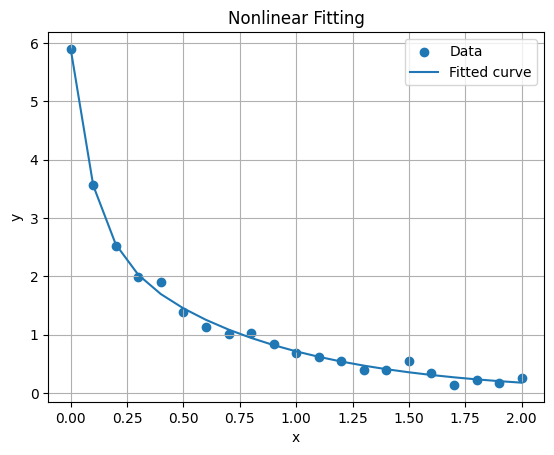

In [7]:


y_fitted = w1_result*np.exp(-w3_result*x) + w2_result*np.exp(-w4_result*x)

plt.figure()
plt.scatter(x, y, label="Data")
plt.plot(x, y_fitted, label="Fitted curve")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Nonlinear Fitting")
plt.grid(True)
plt.legend()
plt.show()


## Interpretation:

### The fitted curve closely follows the observed data points across the given range of $x$, capturing both the rapid initial decay and the slower long-term decrease. This confirms that the chosen nonlinear model and the estimated parameters are appropriate for describing the relationship between $x$ and $y$.


# Question 3: Logistic Regression

## (a) Loading the dataset and converting non-numeric data 

In [26]:
import pandas as pd

df = pd.read_csv("SAHeart.csv") 

# This is to convert non-numeric to numeric, i.e. famhist variable

df["famhist"] = df["famhist"].map({"Absent": 0, "Present": 1})

# And we drop the indices column

df = df.drop(columns=["row.names"])

df.head()






,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
0,160,12.00,5.73,23.11,1,49,25.30,97.20,52,1
1,144,0.01,4.41,28.61,0,55,28.87,2.06,63,1
2,118,0.08,3.48,32.28,1,52,29.14,3.81,46,0
3,170,7.50,6.41,38.03,1,51,31.99,24.26,58,1
4,134,13.60,3.50,27.78,1,60,25.99,57.34,49,1


## (b) Training a logistic regression model for coronary heart disease (CHD) risk classification



In [27]:
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, classification_report




X = df.drop(columns=["chd"])
y = df["chd"]

continuousValued_features = ["sbp","tobacco","ldl","adiposity","typea","obesity","alcohol","age"]
binary_variable = ["famhist"]

preprocess = ColumnTransformer([("scale", StandardScaler(), continuousValued_features ),("keep", "passthrough", binary_variable)])

model = Pipeline([("prep", preprocess),("logreg", LogisticRegression(max_iter=5000, solver="lbfgs"))])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=13, stratify=y)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7155172413793104
AUC: 0.7740131578947369
Confusion matrix:
 [[61 15]
 [18 22]]

Classification report:
               precision    recall  f1-score   support

           0       0.77      0.80      0.79        76
           1       0.59      0.55      0.57        40

    accuracy                           0.72       116
   macro avg       0.68      0.68      0.68       116
weighted avg       0.71      0.72      0.71       116



## Interpretation: 

#### The logistic regression model reaches about 72% accuracy and an AUC of 0.77. This means it can separate patients with and without coronary heart disease fairly well.
#### The model is better at detecting patients who do not have CHD than those who do, since recall is lower for the positive class. While the model is helpful for risk assessment, the fact that it misses some patients with CHD, false negatives, shows that more work may be needed, such as adjusting the decision threshold or trying other models, before using it in clinical practice.


## (c) Predicting risk for the patient

In [28]:
import pandas as pd

x_given = [133, 3.3, 4.6, 34.5, 1, 30, 32, 20, 44]

famhist_data = 1 if x_given[4] > 0 else 0 

x_patient = pd.DataFrame([{
    "sbp": x_given[0],
    "tobacco": x_given[1],
    "ldl": x_given[2],
    "adiposity": x_given[3],
    "famhist": famhist_data,
    "typea": x_given[5],
    "obesity": x_given[6],
    "alcohol": x_given[7],
    "age": x_given[8],
}])

prob_chd = model.predict_proba(x_patient)[0, 1]
pred_chd = model.predict(x_patient)[0]

print("Predicted probability of chd =", prob_chd)
print("Predicted class where 1=high risk or 0=low risk: ", pred_chd)



Predicted probability of chd = 0.2359631861665272
Predicted class where 1=high risk or 0=low risk:  0


## Interpretation: 

#### Based on the trained logistic regression model, the patient is not considered high risk for coronary heart disease. The model estimates the probability of CHD at about 0.24, which categorizes the patient as being at low risk


## (d) Identifying most determinant factors for heart disease


In [29]:

import pandas as pd

coefs = model.named_steps["logreg"].coef_[0]
feature_names = continuousValued_features + binary_variable

coef_table = pd.DataFrame({"feature": feature_names, "coef": coefs, "abs_coef": np.abs(coefs), "odds_ratio": np.exp(coefs)}).sort_values("abs_coef", ascending=False)

coef_table


,feature,coef,abs_coef,odds_ratio
8,famhist,0.963384,0.963384,2.620549
7,age,0.609588,0.609588,1.839673
5,obesity,-0.424127,0.424127,0.654341
3,adiposity,0.379121,0.379121,1.461000
2,ldl,0.321932,0.321932,1.379791
4,typea,0.313098,0.313098,1.367655
1,tobacco,0.293566,0.293566,1.341202
6,alcohol,0.076198,0.076198,1.079177
0,sbp,0.030047,0.030047,1.030503


## Interpretation: 
#### In this model, the most important factors for coronary heart disease in this model are family history and age. Family history is the strongest factor and greatly increases the chance of having heart disease. Age also plays a major role. Other important factors include obesity, adiposity, and LDL cholesterol. Smoking and Type-A behavior increase the risk as well, but to a smaller extent. Systolic blood pressure and alcohol consumption have the weakest effect in this model.


## (e) Discussing whether family history affect CHD chance


In [41]:
beta_famhist = coef_table.loc[coef_table["feature"]=="famhist","coef"].values[0]
OR_famhist   = np.exp(beta_famhist)
print("beta_famhist =", beta_famhist)
print("OR_famhist =", OR_famhist)


beta_famhist = 0.9633838641136657
OR_famhist = 2.6205490689382143


## Interpretation: 
#### This model indicates that family history is a significant predictor of coronary heart disease(CHD), with a coefficient of $$ \beta\approx 0.96$$, and corresponding odds ratio is $$ \text{OR} = e^{0.96} \approx 2.62 $$, meaning that individuals with a family history of CHD have about **2.6 times higher odds** of developing CHD compared to those without when other variables are fixed. This confirms that family history is a strong and meaningful risk factor for CHD.


# Question 4: Neural-Network-Based Solar-Radiation Prediction

## (a) Checking whether the dataset is clean and pre-processing it if not.

In [55]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



seed = 13
np.random.seed(seed)
torch.manual_seed(seed)

df = pd.read_csv("SolarPrediction.csv")

X_cols = ["Pressure", "WindDirection(Degrees)", "Speed", "Humidity", "Temperature"]
y_col  = "Radiation"

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values per column:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nDtypes:\n", df[X_cols + [y_col]].dtypes)
print("\nTarget min/max:", df[y_col].min(), df[y_col].max())




# Preprocessing processes

df = df.drop_duplicates()
df[X_cols + [y_col]] = df[X_cols + [y_col]].apply(pd.to_numeric, errors="coerce")
df = df.dropna(subset=X_cols + [y_col]).reset_index(drop=True)

print("\nAfter cleaning -> Shape:", df.shape)
print("After cleaning -> Missing values:\n", df[X_cols + [y_col]].isna().sum())



Shape: (32686, 11)

Columns: ['UNIXTime', 'Data', 'Time', 'Radiation', 'Temperature', 'Pressure', 'Humidity', 'WindDirection(Degrees)', 'Speed', 'TimeSunRise', 'TimeSunSet']

Missing values per column:
 UNIXTime                  0
Data                      0
Time                      0
Radiation                 0
Temperature               0
Pressure                  0
Humidity                  0
WindDirection(Degrees)    0
Speed                     0
TimeSunRise               0
TimeSunSet                0
dtype: int64

Duplicate rows: 0

Dtypes:
 Pressure                  float64
WindDirection(Degrees)    float64
Speed                     float64
Humidity                    int64
Temperature                 int64
Radiation                 float64
dtype: object

Target min/max: 1.11 1601.26

After cleaning -> Shape: (32686, 11)
After cleaning -> Missing values:
 Pressure                  0
WindDirection(Degrees)    0
Speed                     0
Humidity                  0
Temperature   

### The dataset has 32,686 rows and 11 columns. It’s already clean i.e. no missing values, no duplicates, and all the variables are numbers.The target variable, Radiation, goes from 1.11 to 1601.26, which makes this a regression problem.After some basic checks and preprocessing, nothing needed to be changed, so the data is ready to use for modeling.

## (b) Building a PyTorch neural network with two hidden layers to predict radiation

In [57]:

# defining variabkes X = input (features), y = target variable(labels)


X = df[X_cols].to_numpy(dtype=np.float32)
y = df[[y_col]].to_numpy(dtype=np.float32)



# Splitting data: 70% train, 15% test, and 15% validation 

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=seed)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=seed)



# Scaling data training data

x_scaler = StandardScaler()
y_scaler = StandardScaler()
X_train = x_scaler.fit_transform(X_train).astype(np.float32)
X_val   = x_scaler.transform(X_val).astype(np.float32)
X_test  = x_scaler.transform(X_test).astype(np.float32)
y_train = y_scaler.fit_transform(y_train).astype(np.float32)
y_val   = y_scaler.transform(y_val).astype(np.float32)
y_test  = y_scaler.transform(y_test).astype(np.float32)


# Creating batches and shuffle for training

train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
                          batch_size=256, shuffle=True)
val_loader   = DataLoader(TensorDataset(torch.tensor(X_val), torch.tensor(y_val)),
                          batch_size=512, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Defining two-hidden-layer regression model

model = nn.Sequential(
    nn.Linear(len(X_cols), 64), nn.ReLU(),
    nn.Linear(64, 32), nn.ReLU(),
    nn.Linear(32, 1)
).to(device)

loss_fn = nn.MSELoss()              
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)  



In [58]:

# computing average MSE 

def eval_mse(loader):
    model.eval()
    with torch.no_grad():
        losses = []
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            losses.append(loss_fn(model(xb), yb).item())
    return float(np.mean(losses))


# Stopping if validation does not improve for 'patience' epochs

best_val, best_state = float("inf"), None
patience, bad, max_epochs = 20, 0, 300

for epoch in range(1, max_epochs + 1):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        optimizer.step()

    val_mse = eval_mse(val_loader)
    if val_mse < best_val - 1e-6:
        best_val = val_mse
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        bad = 0
    else:
        bad += 1

    if bad >= patience:
        break

if best_state is not None:
    model.load_state_dict(best_state)
print("Best val MSE (scaled):", best_val)


Best val MSE (scaled): 0.2681648641824722


### The model’s best validation Mean Squared Error is 0.26

## (c) Testing and validating  model 


Test RMSE: 162.348
Test MAE : 97.615906
Test R^2 : 0.7374751567840576


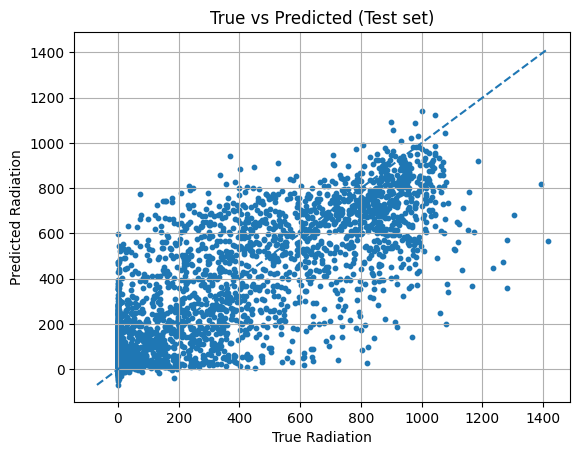

In [59]:
model.eval()
pred_s_list, true_s_list = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        pred_s = model(xb).cpu().numpy()
        pred_s_list.append(pred_s)
        true_s_list.append(yb.numpy())

pred_s = np.vstack(pred_s_list)
true_s = np.vstack(true_s_list)

pred = y_scaler.inverse_transform(pred_s)
true = y_scaler.inverse_transform(true_s)

rmse = np.sqrt(mean_squared_error(true, pred))
mae  = mean_absolute_error(true, pred)
r2   = r2_score(true, pred)

print("\nTest RMSE:", rmse)
print("Test MAE :", mae)
print("Test R^2 :", r2)

plt.figure()
plt.scatter(true, pred, s=10)
plt.xlabel("True Radiation")
plt.ylabel("Predicted Radiation")
plt.title("True vs Predicted (Test set)")
plt.grid(True)



mn = float(min(true.min(), pred.min()))
mx = float(max(true.max(), pred.max()))
plt.plot([mn, mx], [mn, mx], linestyle="--")

plt.show()



### The trained neural network performs well on the test data. The test RMSE is about 162, meaning the model’s predictions deviate from the true radiation values by around 162 units on average.
### The MAE of about 98 confirms a moderate average absolute error. The R² ≈ 0.74 indicates that the model explains roughly 74% of the variability in solar radiation. 
### The scatter plot shows that most values fall close to the y = x line, indicating strong alignment between actual and predicted radiation, with some dispersion at higher radiation levels.

## (d) Comparing the your model to Ali et al. (2023)

In [ ]:

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", trainable_params)


Trainable parameters: 2497


### Ali et al. (2023) reported extremely strong performance from their optimized models, with  **\(R^2\)** values close to **0.98–0.99** and very small RMSE, achieved through carefully tuned neural-network and empirical methods.  

### In comparison, our model attains an **\(R^2\)** of about **0.74** with an RMSE of roughly **162**, while relying on only **2,497 trainable parameters**, reflecting a much simpler architecture.  

### Although the models of Ali et al. are more accurate, our results show that a lightweight neural network can still explain a large proportion of the variability in solar radiation, illustrating the balance between model complexity and predictive performance.


In [2]:
A = [4,6,-1,3]
A.sort()
A

[-1, 3, 4, 6]

In [3]:
def largest_smallest(A):
    n = len(A)
    smallest_pos = []
    largest_neg = []

    for i in range(n):
        A.sort()
        if A[i] > 0:
             smallest_pos.append(A[i])

        elif  A[i]==0:
            pass

        else:
            largest_neg.append(A[i])
    return smallest_pos[:3], largest_neg[-3:]


In [2]:
B = [9,-2,3,-5,8,0,-4,-1,2,1,7,-10,-7]
largest_smallest(B)

([1, 2, 3], [-4, -2, -1])

In [21]:
def largest_small(A):
    n = len(A)
    smallest_pos = []
    largest_neg = []

    for i in range(n):
        A.sort()
        if A[i] > 0:
             smallest_pos.append(A[i])

        if A[i]==0:
            pass

        if A[i] < 0:
            largest_neg.append(A[i])
            
    return smallest_pos[:3], largest_neg[-3:]


In [22]:
N = [100,9,13,1,-3,0,-190,-5, 2,1.1, -0.2,4,-5,-7,1.05,-8,4.2,-0.1]

largest_small(N)


([1, 1.05, 1.1], [-3, -0.2, -0.1])

In [23]:
def small_la(A):
    smal = sorted([x for x in A if x > 0])
    lar = sorted([x for x in A if x < 0])
    return smal[:3], lar [-3:]

In [20]:
N = [100,9,13,1,-3,0,-190,-5, 2,1.1, -0.2,4,-5,-7,1.05,-8,4.2,-0.1]
small_la(N)

([1, 1.05, 1.1], [-3, -0.2, -0.1])

In [11]:
def pair_results(L):
    n = len(L)
    elements = []

    for i in range(n):
        if L[i] % 7 == 0 and L[i] % 11 != 0:
            elements.append(L[i])
    return sum(elements), len(elements)

B = [1,2,154,3,-1, 14,42,9,7,28,77]
pair_results(B)

(91, 4)

In [3]:
N = [100,9,13,1,-3,0,-190,-5, 2,1.1, -0.2,4,-5,-7,1.05,-8,4.2,-0.1]
sum(N)

-82.95

In [ ]:
B = [1,2,154,3,-1, 14,42,9,7,28,77]
sum(B)

5

In [9]:
def is_valid_top(L, pi):
    # Step 1: record position of each vertex in pi
    pos = {pi[i]: i for i in range(len(pi))}
    
    # Step 2: check all edges u -> v
    for u in L:
        for v in L[u]:
            if pos[u] > pos[v]:
                return False
    
    return True
